#**Disease Prediction from Medical Data**

#**Introduction**

The objective of this project is to develop and evaluate machine-learning classification models for predicting breast tumour diagnosis using structured diagnostic data. The analysis uses the Wisconsin Diagnostic Breast Cancer dataset, in which the target variable represents whether a tumour is benign or malignant. Logistic Regression, Support Vector Machine, Random Forest and XGBoost classification algorithms are implemented and compared using multiple performance metrics.

#**Data Description**

The WDBC documentation states that the dataset was created by William H. Wolberg, W. Nick Street and Olvi L. Mangasarian, with the data dated November 1995. The dataset contains diagnostic features calculated from digitised images of fine-needle aspirates. These features describe characteristics of cell nuclei.

- B - Benign
- M - Malignant

#**Import the libraries**

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Train-test split
from sklearn.model_selection import train_test_split

# Feature scaling
from sklearn.preprocessing import StandardScaler

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

#**Load the Dataset**

In [ ]:
columns = [
    "ID",
    "Diagnosis",

    "Radius_Mean",
    "Texture_Mean",
    "Perimeter_Mean",
    "Area_Mean",
    "Smoothness_Mean",
    "Compactness_Mean",
    "Concavity_Mean",
    "Concave_Points_Mean",
    "Symmetry_Mean",
    "Fractal_Dimension_Mean",

    "Radius_SE",
    "Texture_SE",
    "Perimeter_SE",
    "Area_SE",
    "Smoothness_SE",
    "Compactness_SE",
    "Concavity_SE",
    "Concave_Points_SE",
    "Symmetry_SE",
    "Fractal_Dimension_SE",

    "Radius_Worst",
    "Texture_Worst",
    "Perimeter_Worst",
    "Area_Worst",
    "Smoothness_Worst",
    "Compactness_Worst",
    "Concavity_Worst",
    "Concave_Points_Worst",
    "Symmetry_Worst",
    "Fractal_Dimension_Worst"
]

In [ ]:
df = pd.read_csv(
    "/content/wdbc.data",
    header=None,
    names=columns
)

In [ ]:
df.head()

,ID,Diagnosis,Radius_Mean,Texture_Mean,Perimeter_Mean,Area_Mean,Smoothness_Mean,Compactness_Mean,Concavity_Mean,Concave_Points_Mean,...,Radius_Worst,Texture_Worst,Perimeter_Worst,Area_Worst,Smoothness_Worst,Compactness_Worst,Concavity_Worst,Concave_Points_Worst,Symmetry_Worst,Fractal_Dimension_Worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


#**Dataset Inspection**

1) Number of obervations and variables

In [ ]:
print("Number of observations:", df.shape[0])
print("Number of variables:", df.shape[1])

Number of observations: 569
Number of variables: 32


2. Display the first observations

In [ ]:
df.head()

,ID,Diagnosis,Radius_Mean,Texture_Mean,Perimeter_Mean,Area_Mean,Smoothness_Mean,Compactness_Mean,Concavity_Mean,Concave_Points_Mean,...,Radius_Worst,Texture_Worst,Perimeter_Worst,Area_Worst,Smoothness_Worst,Compactness_Worst,Concavity_Worst,Concave_Points_Worst,Symmetry_Worst,Fractal_Dimension_Worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


3. Display the last observations

In [ ]:
df.tail()

,ID,Diagnosis,Radius_Mean,Texture_Mean,Perimeter_Mean,Area_Mean,Smoothness_Mean,Compactness_Mean,Concavity_Mean,Concave_Points_Mean,...,Radius_Worst,Texture_Worst,Perimeter_Worst,Area_Worst,Smoothness_Worst,Compactness_Worst,Concavity_Worst,Concave_Points_Worst,Symmetry_Worst,Fractal_Dimension_Worst
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


4. Examine the structure

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       569 non-null    int64  
 1   Diagnosis                569 non-null    object 
 2   Radius_Mean              569 non-null    float64
 3   Texture_Mean             569 non-null    float64
 4   Perimeter_Mean           569 non-null    float64
 5   Area_Mean                569 non-null    float64
 6   Smoothness_Mean          569 non-null    float64
 7   Compactness_Mean         569 non-null    float64
 8   Concavity_Mean           569 non-null    float64
 9   Concave_Points_Mean      569 non-null    float64
 10  Symmetry_Mean            569 non-null    float64
 11  Fractal_Dimension_Mean   569 non-null    float64
 12  Radius_SE                569 non-null    float64
 13  Texture_SE               569 non-null    float64
 14  Perimeter_SE             5

#**Checking Missing Values**

In [ ]:
missing_values = df.isnull().sum()

print(missing_values)

ID                         0
Diagnosis                  0
Radius_Mean                0
Texture_Mean               0
Perimeter_Mean             0
Area_Mean                  0
Smoothness_Mean            0
Compactness_Mean           0
Concavity_Mean             0
Concave_Points_Mean        0
Symmetry_Mean              0
Fractal_Dimension_Mean     0
Radius_SE                  0
Texture_SE                 0
Perimeter_SE               0
Area_SE                    0
Smoothness_SE              0
Compactness_SE             0
Concavity_SE               0
Concave_Points_SE          0
Symmetry_SE                0
Fractal_Dimension_SE       0
Radius_Worst               0
Texture_Worst              0
Perimeter_Worst            0
Area_Worst                 0
Smoothness_Worst           0
Compactness_Worst          0
Concavity_Worst            0
Concave_Points_Worst       0
Symmetry_Worst             0
Fractal_Dimension_Worst    0
dtype: int64


In [ ]:
print(
    "Total missing values:",
    df.isnull().sum().sum()
)

Total missing values: 0


#**Checking Duplicates**

In [ ]:
print(
    "Number of duplicate rows:",
    df.duplicated().sum()
)

Number of duplicate rows: 0


#**Examination of Target Variable**

In [ ]:
print(df["Diagnosis"].value_counts())

Diagnosis
B    357
M    212
Name: count, dtype: int64


In [ ]:
print(
    df["Diagnosis"].value_counts(normalize=True) * 100
)

Diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


#**Visualisation of the Target Variable**

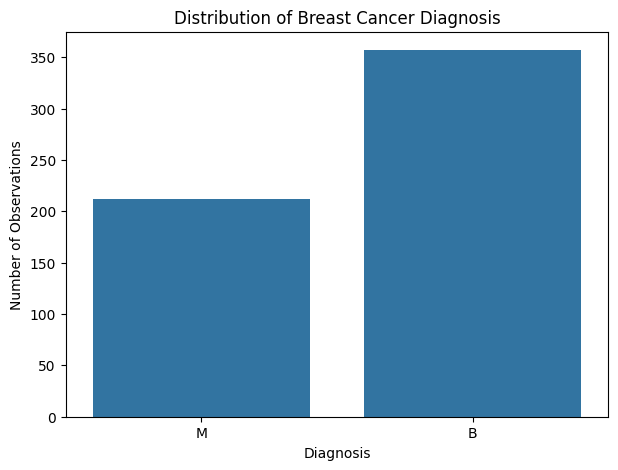

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x="Diagnosis",
    data=df
)

plt.title("Distribution of Breast Cancer Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Observations")

plt.show()

#**Conversion of Diagnosis into Numerical Values**

In [ ]:
df["Diagnosis"] = df["Diagnosis"].map({
    "B": 0,
    "M": 1
})

In [ ]:
df["Diagnosis"].value_counts()

,count
Diagnosis,
0,357
1,212


#**Removing the ID Variable**

In [ ]:
df = df.drop("ID", axis=1)

In [ ]:
df.head()

,Diagnosis,Radius_Mean,Texture_Mean,Perimeter_Mean,Area_Mean,Smoothness_Mean,Compactness_Mean,Concavity_Mean,Concave_Points_Mean,Symmetry_Mean,...,Radius_Worst,Texture_Worst,Perimeter_Worst,Area_Worst,Smoothness_Worst,Compactness_Worst,Concavity_Worst,Concave_Points_Worst,Symmetry_Worst,Fractal_Dimension_Worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


#**Descriptive Statistics**

In [ ]:
df.describe()

,Diagnosis,Radius_Mean,Texture_Mean,Perimeter_Mean,Area_Mean,Smoothness_Mean,Compactness_Mean,Concavity_Mean,Concave_Points_Mean,Symmetry_Mean,...,Radius_Worst,Texture_Worst,Perimeter_Worst,Area_Worst,Smoothness_Worst,Compactness_Worst,Concavity_Worst,Concave_Points_Worst,Symmetry_Worst,Fractal_Dimension_Worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


#**Exploratory Data Analysis**

##**1. Correlation Heatmap**

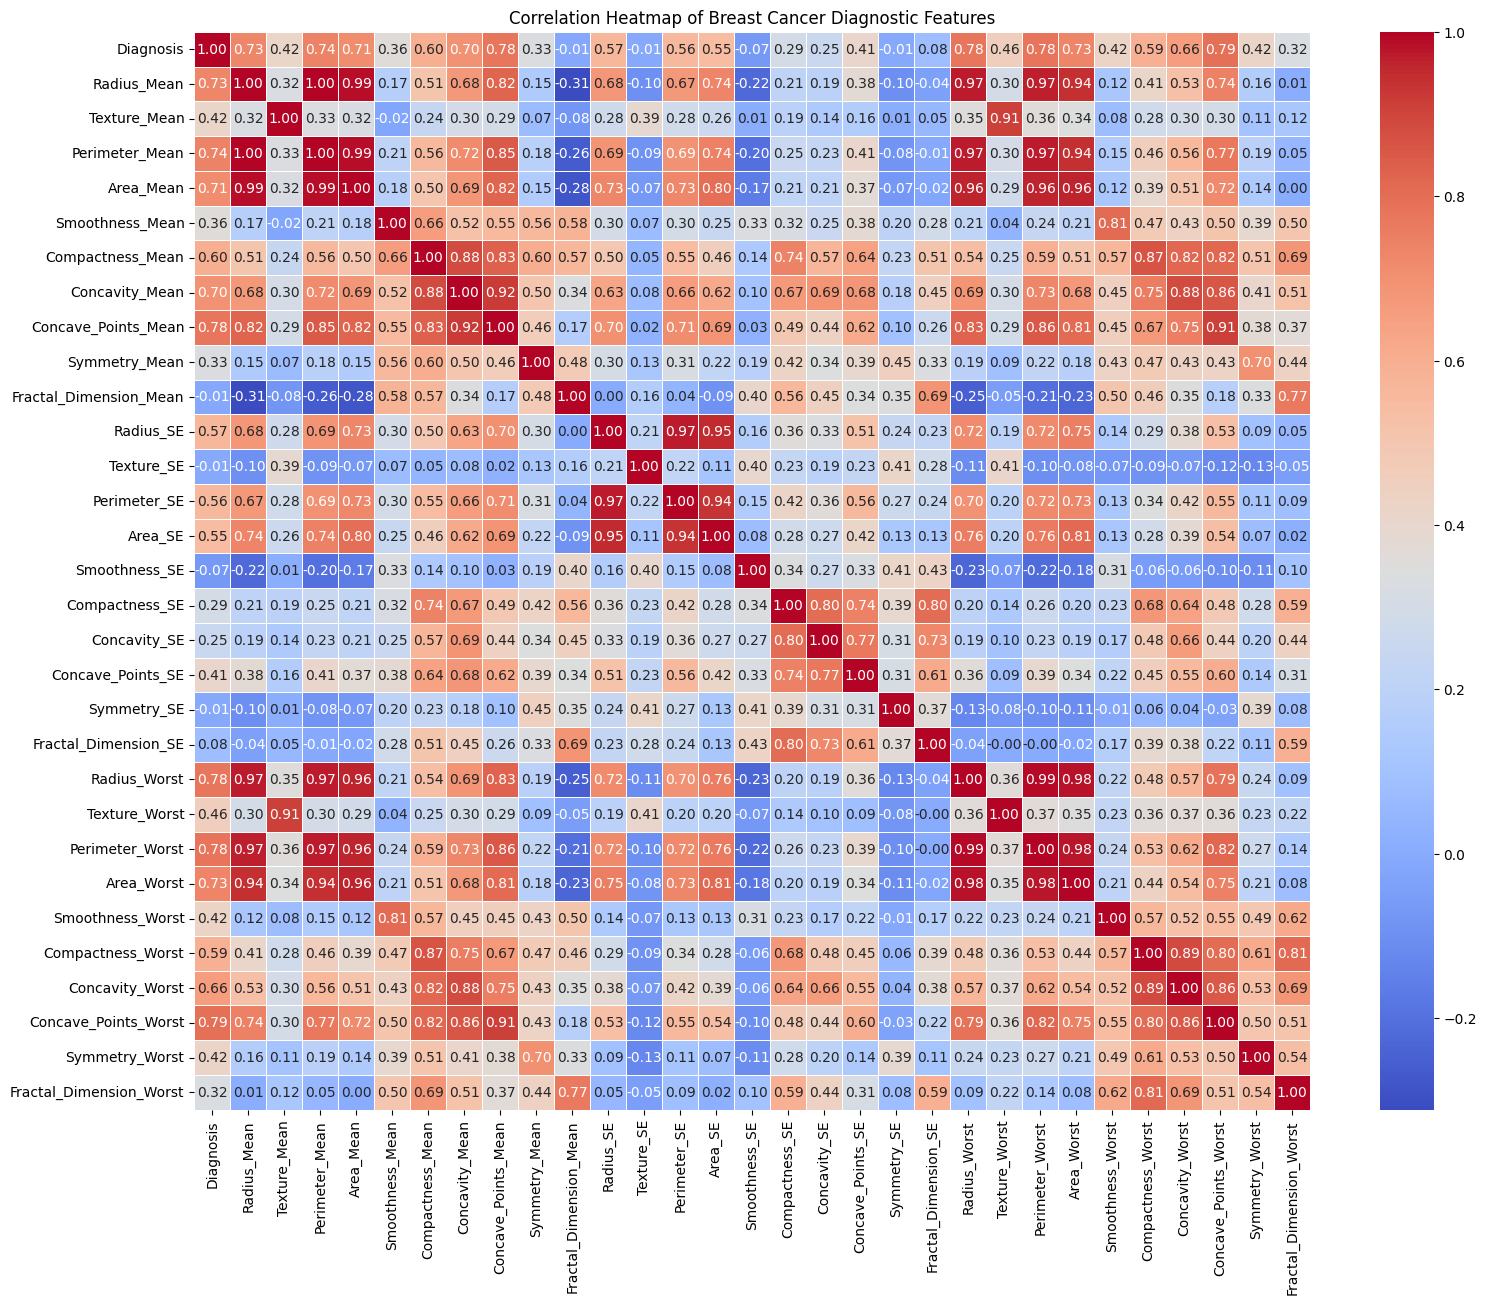

In [ ]:
plt.figure(figsize=(18, 14))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlation Heatmap of Breast Cancer Diagnostic Features"
)

plt.show()

#**Examination of Features by Diagnosis**

1. Mean Radius

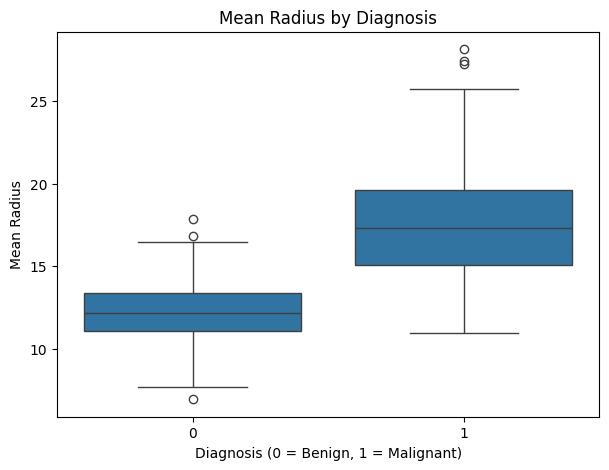

In [ ]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    x="Diagnosis",
    y="Radius_Mean",
    data=df
)

plt.title("Mean Radius by Diagnosis")
plt.xlabel("Diagnosis (0 = Benign, 1 = Malignant)")
plt.ylabel("Mean Radius")

plt.show()

2. Mean Area

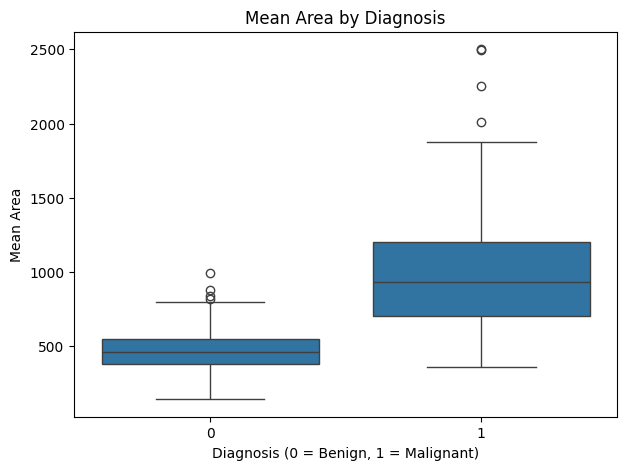

In [ ]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    x="Diagnosis",
    y="Area_Mean",
    data=df
)

plt.title("Mean Area by Diagnosis")
plt.xlabel("Diagnosis (0 = Benign, 1 = Malignant)")
plt.ylabel("Mean Area")

plt.show()

#**Separation of X and Y**

In [ ]:
X = df.drop("Diagnosis", axis=1)

y = df["Diagnosis"]

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


#**Split the Dataset**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
print("Training observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])

Training observations: 455
Testing observations: 114


#**Feature Scaling**

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

#**Model 1 - Logistic Regression**

##**1. Train the model**

In [ ]:
logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000)

##**2. Make predictions**

In [ ]:
y_pred_logistic = logistic_model.predict(
    X_test_scaled
)

##**3. Evaluation of Logistic Regression**

1. Accuracy

In [ ]:
accuracy_logistic = accuracy_score(
    y_test,
    y_pred_logistic
)

print("Accuracy:", accuracy_logistic)

Accuracy: 0.9649122807017544


2. Precision

In [ ]:
precision_logistic = precision_score(
    y_test,
    y_pred_logistic
)

print("Precision:", precision_logistic)

Precision: 0.975


3. Recall

In [ ]:
recall_logistic = recall_score(
    y_test,
    y_pred_logistic
)

print("Recall:", recall_logistic)

Recall: 0.9285714285714286


4. F1-score

In [ ]:
f1_logistic = f1_score(
    y_test,
    y_pred_logistic
)

print("F1-score:", f1_logistic)

F1-score: 0.9512195121951219


5. ROC-AUC

In [ ]:
y_prob_logistic = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

roc_auc_logistic = roc_auc_score(
    y_test,
    y_prob_logistic
)

print("ROC-AUC:", roc_auc_logistic)

ROC-AUC: 0.996031746031746


##**4. Logistic Regression Classification Report**

In [ ]:
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=["Benign", "Malignant"]
    )
)

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



##**5. Logistic Regression Confusion Matrix**

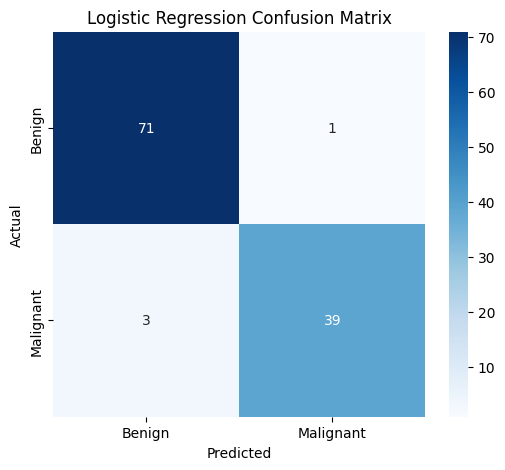

In [ ]:
cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#**Model 2 - Support Vector Machine**

##**1. Train the model**

In [ ]:
svm_model = SVC(
    probability=True,
    random_state=42
)

svm_model.fit(
    X_train_scaled,
    y_train
)

SVC(probability=True, random_state=42)

##**2. Make predictions**

In [ ]:
y_pred_svm = svm_model.predict(
    X_test_scaled
)

##**3. Evaluation of SVM**

In [ ]:
accuracy_svm = accuracy_score(
    y_test,
    y_pred_svm
)

precision_svm = precision_score(
    y_test,
    y_pred_svm
)

recall_svm = recall_score(
    y_test,
    y_pred_svm
)

f1_svm = f1_score(
    y_test,
    y_pred_svm
)

y_prob_svm = svm_model.predict_proba(
    X_test_scaled
)[:, 1]

roc_auc_svm = roc_auc_score(
    y_test,
    y_prob_svm
)

print("SVM Accuracy:", accuracy_svm)
print("SVM Precision:", precision_svm)
print("SVM Recall:", recall_svm)
print("SVM F1-score:", f1_svm)
print("SVM ROC-AUC:", roc_auc_svm)

SVM Accuracy: 0.9736842105263158
SVM Precision: 1.0
SVM Recall: 0.9285714285714286
SVM F1-score: 0.9629629629629629
SVM ROC-AUC: 0.9947089947089947


#**Model 3 - Random Forest**

##**1. Train the model**

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

##**2. Make Predictions**

In [ ]:
y_pred_rf = rf_model.predict(
    X_test
)

##**3. Evaluation of Random Forest**

In [ ]:
accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

precision_rf = precision_score(
    y_test,
    y_pred_rf
)

recall_rf = recall_score(
    y_test,
    y_pred_rf
)

f1_rf = f1_score(
    y_test,
    y_pred_rf
)

y_prob_rf = rf_model.predict_proba(
    X_test
)[:, 1]

roc_auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)

print("Random Forest Accuracy:", accuracy_rf)
print("Random Forest Precision:", precision_rf)
print("Random Forest Recall:", recall_rf)
print("Random Forest F1-score:", f1_rf)
print("Random Forest ROC-AUC:", roc_auc_rf)

Random Forest Accuracy: 0.9736842105263158
Random Forest Precision: 1.0
Random Forest Recall: 0.9285714285714286
Random Forest F1-score: 0.9629629629629629
Random Forest ROC-AUC: 0.9928902116402116


#**Model 4 - XGBoost**

##**1. Train the model**

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

##**2. Make predictions**

In [ ]:
y_pred_xgb = xgb_model.predict(
    X_test
)

##**3. Evaluation of XGBoost**

In [ ]:
accuracy_xgb = accuracy_score(
    y_test,
    y_pred_xgb
)

precision_xgb = precision_score(
    y_test,
    y_pred_xgb
)

recall_xgb = recall_score(
    y_test,
    y_pred_xgb
)

f1_xgb = f1_score(
    y_test,
    y_pred_xgb
)

y_prob_xgb = xgb_model.predict_proba(
    X_test
)[:, 1]

roc_auc_xgb = roc_auc_score(
    y_test,
    y_prob_xgb
)

print("XGBoost Accuracy:", accuracy_xgb)
print("XGBoost Precision:", precision_xgb)
print("XGBoost Recall:", recall_xgb)
print("XGBoost F1-score:", f1_xgb)
print("XGBoost ROC-AUC:", roc_auc_xgb)

XGBoost Accuracy: 0.9649122807017544
XGBoost Precision: 1.0
XGBoost Recall: 0.9047619047619048
XGBoost F1-score: 0.95
XGBoost ROC-AUC: 0.9943783068783068


#**Initial Model Evaluation**

##**1. Model Comparison Table**

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy_logistic,
        accuracy_svm,
        accuracy_rf,
        accuracy_xgb
    ],

    "Precision": [
        precision_logistic,
        precision_svm,
        precision_rf,
        precision_xgb
    ],

    "Recall": [
        recall_logistic,
        recall_svm,
        recall_rf,
        recall_xgb
    ],

    "F1-Score": [
        f1_logistic,
        f1_svm,
        f1_rf,
        f1_xgb
    ],

    "ROC-AUC": [
        roc_auc_logistic,
        roc_auc_svm,
        roc_auc_rf,
        roc_auc_xgb
    ]
})
print("Initial Model Performance:")
results.round(4)

Initial Model Performance:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.9649,0.975,0.9286,0.9512,0.9960
1,SVM,0.9737,1.000,0.9286,0.9630,0.9947
2,Random Forest,0.9737,1.000,0.9286,0.9630,0.9929
3,XGBoost,0.9649,1.000,0.9048,0.9500,0.9944


##**2. Visual Model Comparison**

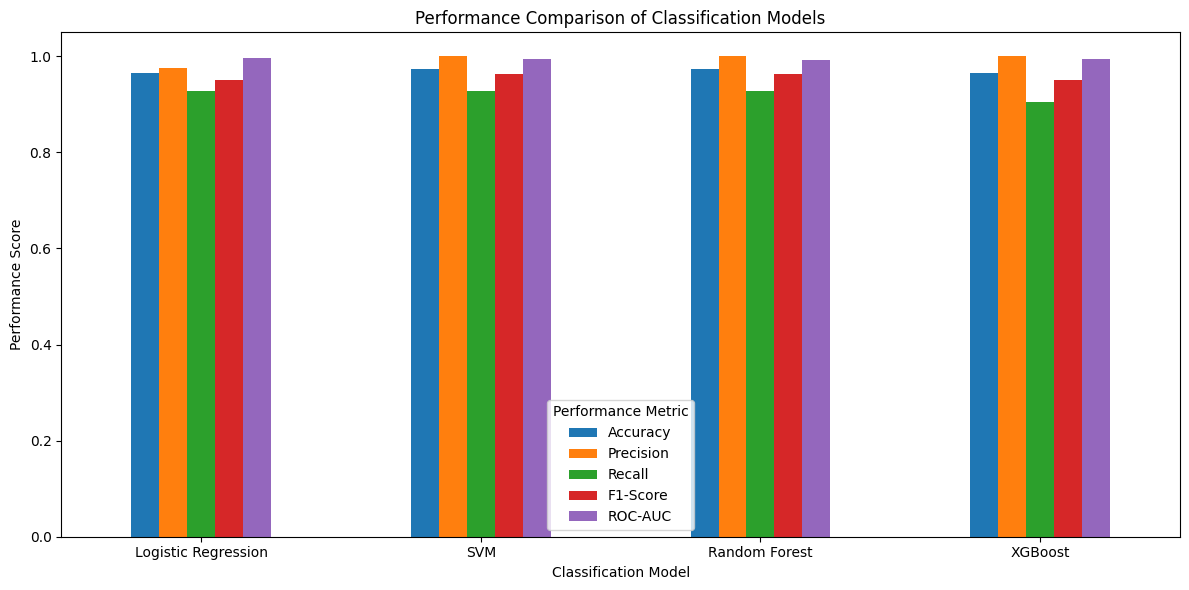

In [ ]:
results.set_index("Model")[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Performance Comparison of Classification Models")
plt.xlabel("Classification Model")
plt.ylabel("Performance Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Performance Metric")

plt.tight_layout()
plt.show()

#**Cross-Validation**

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Create 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

##**Logistic Regression Cross-Validation**

In [ ]:
# Perform 5-fold cross-validation for Logistic Regression

logistic_cv_scores = cross_val_score(
    LogisticRegression(max_iter=1000),
    X_train_scaled,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("Logistic Regression CV ROC-AUC scores:")
print(logistic_cv_scores)

print("Mean Logistic Regression CV ROC-AUC:",
      round(logistic_cv_scores.mean(), 4))

Logistic Regression CV ROC-AUC scores:
[0.99484004 0.99896801 1.         0.9871001  0.99793602]
Mean Logistic Regression CV ROC-AUC: 0.9958


##**SVM Cross-Validation**



In [ ]:
# Perform 5-fold cross-validation for SVM

svm_cv_scores = cross_val_score(
    SVC(probability=True, random_state=42),
    X_train_scaled,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("SVM CV ROC-AUC scores:")
print(svm_cv_scores)

print("Mean SVM CV ROC-AUC:",
      round(svm_cv_scores.mean(), 4))

SVM CV ROC-AUC scores:
[0.99690402 0.99896801 0.99793602 0.98606811 0.99432405]
Mean SVM CV ROC-AUC: 0.9948


##**Random Forest Cross-Validation**

In [ ]:
# Perform 5-fold cross-validation for Random Forest

rf_cv_scores = cross_val_score(
    RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("Random Forest CV ROC-AUC scores:")
print(rf_cv_scores)

print("Mean Random Forest CV ROC-AUC:",
      round(rf_cv_scores.mean(), 4))

Random Forest CV ROC-AUC scores:
[0.98271414 1.         0.99303406 0.98632611 0.98245614]
Mean Random Forest CV ROC-AUC: 0.9889


##**XGBoost Cross-Validation**

In [ ]:
# Perform 5-fold cross-validation for XGBoost

xgb_cv_scores = cross_val_score(
    XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        random_state=42,
        eval_metric="logloss"
    ),
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("XGBoost CV ROC-AUC scores:")
print(xgb_cv_scores)

print("Mean XGBoost CV ROC-AUC:",
      round(xgb_cv_scores.mean(), 4))

XGBoost CV ROC-AUC scores:
[0.99432405 0.99896801 0.99432405 0.9876161  0.99484004]
Mean XGBoost CV ROC-AUC: 0.994


##**Cross-validation summary**

In [ ]:
# Summarise the mean cross-validation ROC-AUC scores

cv_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest",
        "XGBoost"
    ],

    "Mean CV ROC-AUC": [
        logistic_cv_scores.mean(),
        svm_cv_scores.mean(),
        rf_cv_scores.mean(),
        xgb_cv_scores.mean()
    ],

    "Standard Deviation": [
        logistic_cv_scores.std(),
        svm_cv_scores.std(),
        rf_cv_scores.std(),
        xgb_cv_scores.std()
    ]
})

display(cv_results.round(4))

,Model,Mean CV ROC-AUC,Standard Deviation
0,Logistic Regression,0.9958,0.0047
1,SVM,0.9948,0.0046
2,Random Forest,0.9889,0.0067
3,XGBoost,0.9940,0.0036


#**Hyperparameter Tuning**

In [ ]:
from sklearn.model_selection import GridSearchCV

##**Tune Logistic Regression**

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define different Logistic Regression parameters to test

logistic_params = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

# Perform grid search using 5-fold cross-validation

logistic_grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    logistic_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

# Train and test the different parameter combinations
logistic_grid.fit(X_train_scaled, y_train)

# Display the best parameters
print("Best Logistic Regression parameters:")
print(logistic_grid.best_params_)

# Display the best cross-validation score
print("Best Logistic Regression CV ROC-AUC:",
      round(logistic_grid.best_score_, 4))

Best Logistic Regression parameters:
{'C': 1, 'solver': 'liblinear'}
Best Logistic Regression CV ROC-AUC: 0.9958


##**Tune SVM**

In [ ]:
# Define different SVM parameters to test

svm_params = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.01, 0.1, 1],
    "kernel": ["rbf", "linear"]
}

# Perform grid search

svm_grid = GridSearchCV(
    SVC(probability=True, random_state=42),
    svm_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

# Train the models
svm_grid.fit(X_train_scaled, y_train)

# Display the best parameters
print("Best SVM parameters:")
print(svm_grid.best_params_)

# Display the best cross-validation score
print("Best SVM CV ROC-AUC:",
      round(svm_grid.best_score_, 4))

Best SVM parameters:
{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best SVM CV ROC-AUC: 0.9954


##**Tune Random Forest**

In [ ]:
# Define different Random Forest parameters to test

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10]
}

# Perform grid search

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

# Train the models
rf_grid.fit(X_train, y_train)

# Display the best parameters
print("Best Random Forest parameters:")
print(rf_grid.best_params_)

# Display the best cross-validation score
print("Best Random Forest CV ROC-AUC:",
      round(rf_grid.best_score_, 4))

Best Random Forest parameters:
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Best Random Forest CV ROC-AUC: 0.989


##**Tune XGBoost**

In [ ]:
# Define different XGBoost parameters to test

xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2]
}

# Perform grid search

xgb_grid = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    xgb_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

# Train the models
xgb_grid.fit(X_train, y_train)

# Display the best parameters
print("Best XGBoost parameters:")
print(xgb_grid.best_params_)

# Display the best cross-validation score
print("Best XGBoost CV ROC-AUC:",
      round(xgb_grid.best_score_, 4))

Best XGBoost parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best XGBoost CV ROC-AUC: 0.994


#**Tuned Model Evaluation**

In [ ]:
# Store the best tuned models in a dictionary

tuned_models = {
    "Logistic Regression": logistic_grid.best_estimator_,
    "SVM": svm_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_,
    "XGBoost": xgb_grid.best_estimator_
}

In [ ]:
# Create an empty list to store the results
tuned_results = []

# Re-import the necessary metric functions to ensure they are callable
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Loop through each tuned model
for name, model in tuned_models.items():

    # Logistic Regression and SVM require scaled data
    if name in ["Logistic Regression", "SVM"]:
        X_test_model = X_test_scaled
    else:
        X_test_model = X_test

    # Make predictions
    predictions = model.predict(X_test_model);

    # Obtain probability predictions
    probabilities = model.predict_proba(X_test_model)[:, 1]

    # Calculate performance metrics
    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1-Score": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, probabilities)
    })

# Convert the results into a DataFrame
tuned_results = pd.DataFrame(tuned_results)

# Display the results
print("Tuned Model Performance:")
display(tuned_results.round(4))

Tuned Model Performance:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.9737,0.9756,0.9524,0.9639,0.9960
1,SVM,0.9825,1.0000,0.9524,0.9756,0.9960
2,Random Forest,0.9737,1.0000,0.9286,0.9630,0.9929
3,XGBoost,0.9649,1.0000,0.9048,0.9500,0.9944


#**Original vs Tuned Model Comparison**

In [ ]:
# Add a column identifying the original models

original_results = results.copy()
original_results["Version"] = "Original"

# Add a column identifying the tuned models

tuned_results_comparison = tuned_results.copy()
tuned_results_comparison["Version"] = "Tuned"

# Combine the two result tables

combined_results = pd.concat(
    [original_results, tuned_results_comparison],
    ignore_index=True
)

# Display the comparison

display(combined_results.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Version
0,Logistic Regression,0.9649,0.9750,0.9286,0.9512,0.9960,Original
1,SVM,0.9737,1.0000,0.9286,0.9630,0.9947,Original
2,Random Forest,0.9737,1.0000,0.9286,0.9630,0.9929,Original
3,XGBoost,0.9649,1.0000,0.9048,0.9500,0.9944,Original
4,Logistic Regression,0.9737,0.9756,0.9524,0.9639,0.9960,Tuned
5,SVM,0.9825,1.0000,0.9524,0.9756,0.9960,Tuned
6,Random Forest,0.9737,1.0000,0.9286,0.9630,0.9929,Tuned
7,XGBoost,0.9649,1.0000,0.9048,0.9500,0.9944,Tuned


##**Compare ROC-AUC**

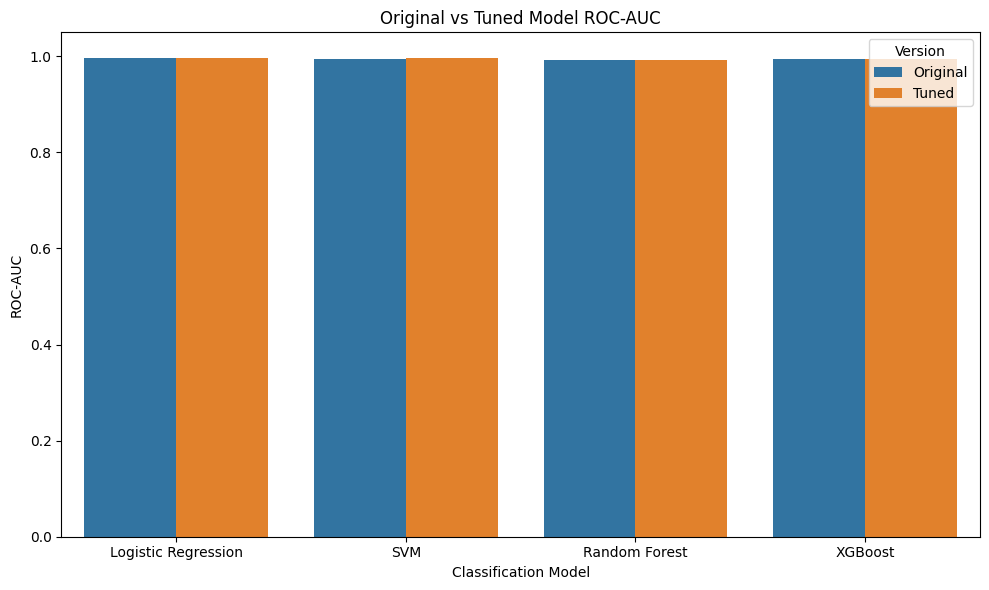

In [ ]:
# Plot the ROC-AUC of the original and tuned models

plt.figure(figsize=(10, 6))

sns.barplot(
    data=combined_results,
    x="Model",
    y="ROC-AUC",
    hue="Version"
)

plt.title("Original vs Tuned Model ROC-AUC")
plt.xlabel("Classification Model")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##**Compare Recall**

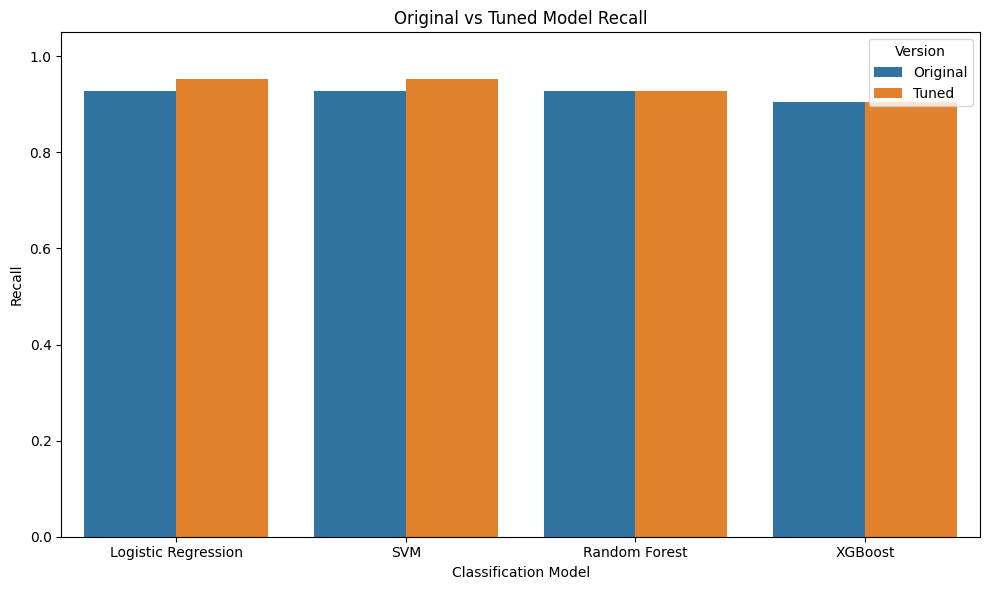

In [ ]:
# Plot recall for original and tuned models

plt.figure(figsize=(10, 6))

sns.barplot(
    data=combined_results,
    x="Model",
    y="Recall",
    hue="Version"
)

plt.title("Original vs Tuned Model Recall")
plt.xlabel("Classification Model")
plt.ylabel("Recall")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#**ROC Curve Analysis**

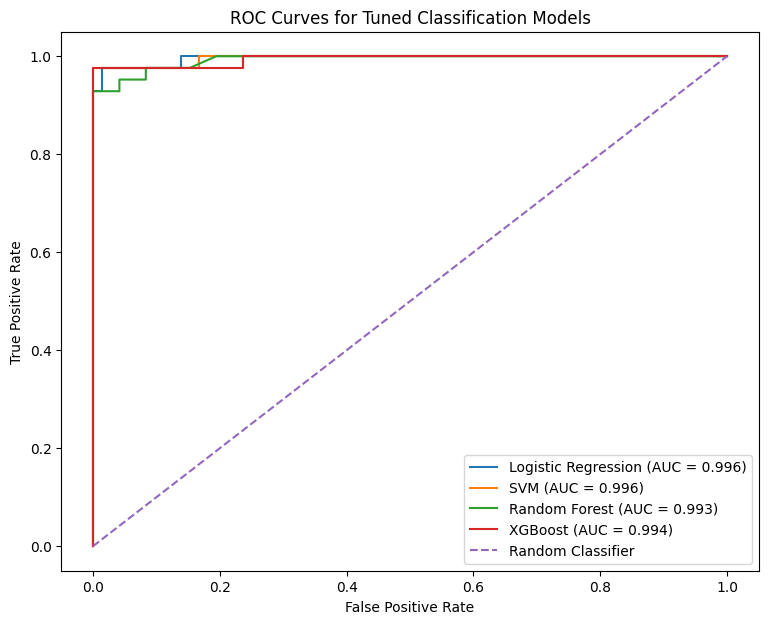

In [ ]:
# Create a figure for the ROC curves

plt.figure(figsize=(9, 7))

# Loop through the tuned models

for name, model in tuned_models.items():

    # Select the appropriate test data
    if name in ["Logistic Regression", "SVM"]:
        X_test_model = X_test_scaled
    else:
        X_test_model = X_test

    # Calculate predicted probabilities
    probabilities = model.predict_proba(X_test_model)[:, 1]

    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(y_test, probabilities)

    # Calculate ROC-AUC
    auc_score = roc_auc_score(y_test, probabilities)

    # Plot the ROC curve
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

# Add random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Tuned Classification Models")
plt.legend()
plt.show()

#**Feature Importance**

In [ ]:
# Get the best Random Forest model

best_rf_model = rf_grid.best_estimator_

# Extract feature importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf_model.feature_importances_
})

# Sort features from most to least important

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display the top 10 features

print("Top 10 Most Important Features:")
display(feature_importance.head(10))

Top 10 Most Important Features:


,Feature,Importance
23,Area_Worst,0.151412
27,Concave_Points_Worst,0.126497
20,Radius_Worst,0.093475
22,Perimeter_Worst,0.083642
7,Concave_Points_Mean,0.081082
2,Perimeter_Mean,0.077126
0,Radius_Mean,0.061990
6,Concavity_Mean,0.050818
3,Area_Mean,0.045916
26,Concavity_Worst,0.030022


##**Plot the top 10 features**

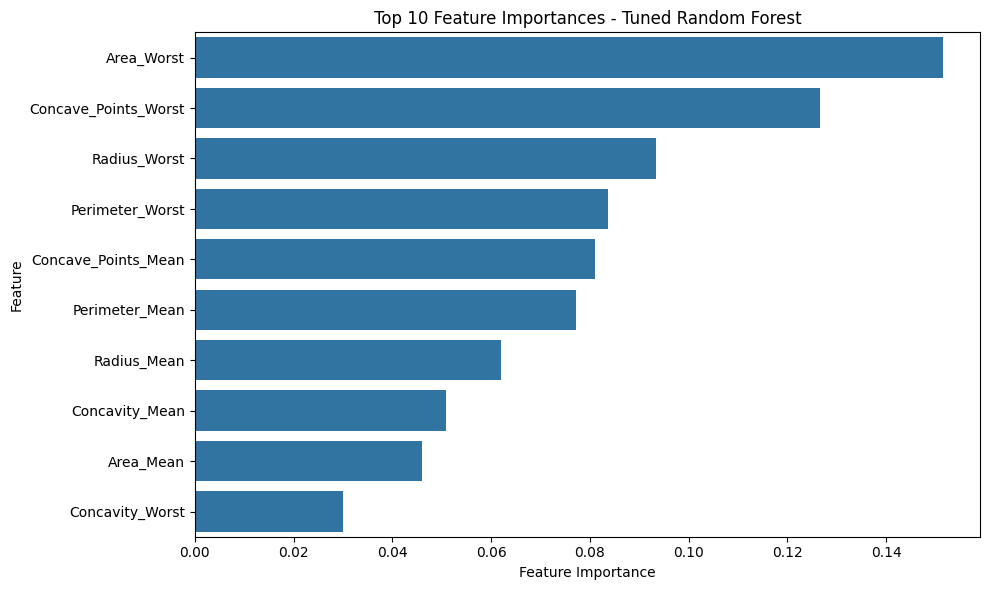

In [ ]:
# Select the top 10 features

top_features = feature_importance.head(10)

# Create the feature importance plot

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances - Tuned Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

#**Final Model Discussion**

##**Identification of the Best Model**

In [ ]:
# Identify the model with the highest ROC-AUC

best_roc_auc_model = tuned_results.loc[
    tuned_results["ROC-AUC"].idxmax()
]

print("Model with highest ROC-AUC:")
print(best_roc_auc_model)

Model with highest ROC-AUC:
Model        Logistic Regression
Accuracy                0.973684
Precision                0.97561
Recall                  0.952381
F1-Score                0.963855
ROC-AUC                 0.996032
Name: 0, dtype: object


In [ ]:
# Identify the model with the highest recall

best_recall_model = tuned_results.loc[
    tuned_results["Recall"].idxmax()
]

print("\nModel with highest Recall:")
print(best_recall_model)


Model with highest Recall:
Model        Logistic Regression
Accuracy                0.973684
Precision                0.97561
Recall                  0.952381
F1-Score                0.963855
ROC-AUC                 0.996032
Name: 0, dtype: object


In [ ]:
# Identify the model with the highest F1-score

best_f1_model = tuned_results.loc[
    tuned_results["F1-Score"].idxmax()
]

print("\nModel with highest F1-Score:")
print(best_f1_model)


Model with highest F1-Score:
Model             SVM
Accuracy     0.982456
Precision         1.0
Recall       0.952381
F1-Score      0.97561
ROC-AUC      0.996032
Name: 1, dtype: object


##**Display**

In [ ]:
print("===== FINAL MODEL COMPARISON =====")

print("\nHighest ROC-AUC:")
print(best_roc_auc_model)

print("\nHighest Recall:")
print(best_recall_model)

print("\nHighest F1-Score:")
print(best_f1_model)

===== FINAL MODEL COMPARISON =====

Highest ROC-AUC:
Model        Logistic Regression
Accuracy                0.973684
Precision                0.97561
Recall                  0.952381
F1-Score                0.963855
ROC-AUC                 0.996032
Name: 0, dtype: object

Highest Recall:
Model        Logistic Regression
Accuracy                0.973684
Precision                0.97561
Recall                  0.952381
F1-Score                0.963855
ROC-AUC                 0.996032
Name: 0, dtype: object

Highest F1-Score:
Model             SVM
Accuracy     0.982456
Precision         1.0
Recall       0.952381
F1-Score      0.97561
ROC-AUC      0.996032
Name: 1, dtype: object


#**Conclusion and Limitations**

In [ ]:
# Display the final tuned model results

final_summary = tuned_results[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
].copy()

display(final_summary.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.9737,0.9756,0.9524,0.9639,0.9960
1,SVM,0.9825,1.0000,0.9524,0.9756,0.9960
2,Random Forest,0.9737,1.0000,0.9286,0.9630,0.9929
3,XGBoost,0.9649,1.0000,0.9048,0.9500,0.9944


In [ ]:
# Save the final model comparison to a CSV file

final_summary.to_csv(
    "breast_cancer_model_results.csv",
    index=False
)

print("Final results saved successfully.")

Final results saved successfully.


##**Final Model Results and Discussion**

The final results indicate that all four classification algorithms achieved strong predictive performance on the Wisconsin Diagnostic Breast Cancer dataset. Accuracy ranged from 96.49% for XGBoost to 98.25% for SVM. SVM achieved the highest accuracy at 98.25%, together with a precision of 100.00% and an F1-score of 97.56%.

Logistic Regression and SVM produced the highest ROC-AUC value of 0.9960. Both models also achieved the highest recall of 95.24%. This indicates that the two models demonstrated strong ability to distinguish between benign and malignant observations while identifying a high proportion of the malignant cases.

Random Forest achieved an accuracy of 97.37%, precision of 100.00%, recall of 92.86%, F1-score of 96.30% and ROC-AUC of 0.9929. XGBoost achieved an accuracy of 96.49%, precision of 100.00%, recall of 90.48%, F1-score of 95.00% and ROC-AUC of 0.9944.

Overall, the results show that SVM performed strongly across the reported evaluation measures, particularly in terms of accuracy, precision and F1-score, while also sharing the highest ROC-AUC and recall with Logistic Regression. Therefore, the results provide evidence that SVM was highly effective on this particular test set. However, model selection should consider multiple performance measures rather than relying on accuracy alone, particularly because false-negative predictions are important in a medical classification problem.

##**Conclusion**

This project developed and evaluated four classification techniques for predicting breast cancer diagnosis using the Wisconsin Diagnostic Breast Cancer dataset. Logistic Regression, Support Vector Machine, Random Forest and XGBoost were implemented and evaluated using accuracy, precision, recall, F1-score and ROC-AUC.

Cross-validation and hyperparameter tuning were subsequently introduced to improve the reliability and generalisation of the models. The tuned models were evaluated on an independent test set and compared with their original versions. This provided a more comprehensive assessment of whether model optimisation resulted in improved predictive performance.

Particular attention was given to recall because the classification task involves distinguishing malignant from benign cases. A false negative represents a malignant observation classified as benign, making recall an important performance measure alongside ROC-AUC, precision and F1-score.

Feature importance analysis was also performed using the tuned Random Forest model to identify the diagnostic variables that contributed most strongly to its predictions. These results can provide useful insights into the structure of the predictive model, although model-based feature importance should not be interpreted as evidence of clinical causation.

Limitations

Several limitations should be considered. First, the dataset contains a relatively small number of observations compared with large-scale modern medical datasets. Second, the features are derived from digitised images of breast masses and therefore the results may not directly generalise to all clinical populations or healthcare settings. Third, the models are based on the available dataset and should not be interpreted as replacements for professional medical diagnosis.

Future work could include additional external validation using an independent medical dataset, more extensive hyperparameter optimisation, probability calibration and evaluation using additional clinically relevant measures. Such extensions could provide stronger evidence regarding the reliability and generalisability of the predictive models.